In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [31]:
df = pd.read_csv('../DataSet/ml_ready_data.csv')

In [32]:
df

,Job_Title,Industry,Job_Status,AI_Impact_Level,Median_Salary_(USD),Required_Education,Experience_Required_(Years),Job_Openings_(2024),Projected_Openings_(2030),Remote_Work_Ratio,Automation_Risk,Location,Gender_Diversity,Growth_Rate,Risk_Category,Seniority,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Is_High_Risk
0,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0,-0.438781,-1.071137,0.829182,1
1,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0,-1.244947,-1.454739,0.479884,1
2,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0,0.332335,-1.106010,1.702427,1
3,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0,-0.684136,-1.629104,-1.266606,1
4,3,3,0,0,0.397944,4,-0.846500,0.484342,-1.203914,-0.495603,-1.479939,4,-1.510780,-0.344427,1,0,-1.595454,0.637635,0.217910,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0,0.577690,0.463270,-1.441255,0
28625,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0,-1.069694,-1.350121,-0.829984,0
28626,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0,0.437487,-1.245502,-1.703229,0
28627,3,2,0,2,-1.344789,1,-1.182108,-0.615865,-1.608389,-1.704488,0.849130,2,1.191724,-0.362334,0,0,-1.595454,0.602762,0.916506,0


In [33]:
df.drop(columns=['Seniority'], inplace=True)

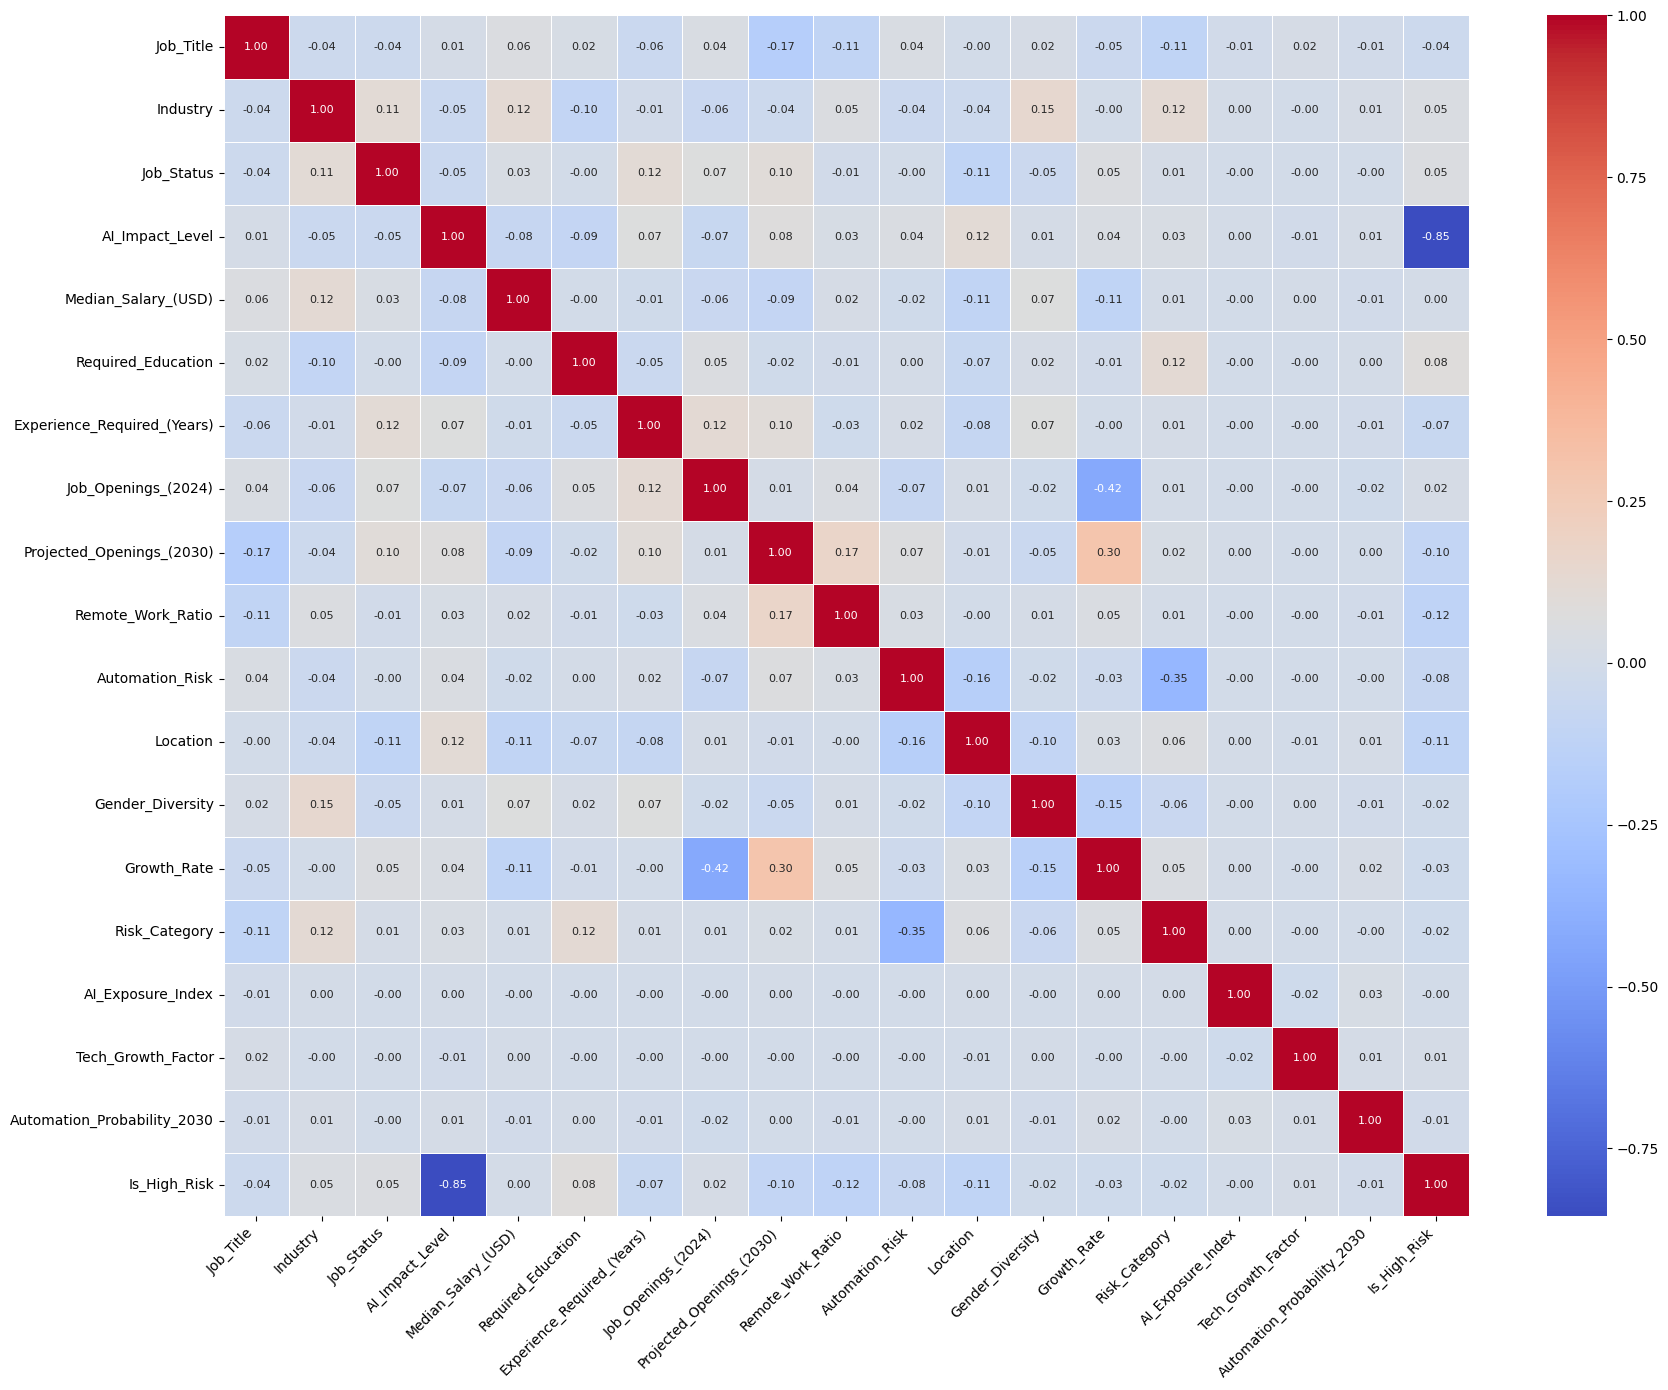

In [34]:
plt.figure(figsize=(18,14))

sns.heatmap(
df.corr(),
annot=True,
fmt=".2f",
cmap="coolwarm",
linewidths=0.5,
annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
suspicious_columns = [
    'Is_High_Risk', 
    'Automation_Risk', 
    'Risk_Category', 
    'Automation_Probability_2030', 
    'AI_Exposure_Index'
]

In [36]:
features = df.drop(columns=['AI_Impact_Level'] + suspicious_columns, errors='ignore')
target = df['AI_Impact_Level']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(features ,target , test_size=0.2, random_state=42)

In [38]:
estimators_to_test = [50, 75, 100, 250, 300 ,400 ,500]

In [39]:
print("Starting Hyperparameter Tuning...\n")
for n in estimators_to_test:
    # 1. Initialize the model with the current number of estimators and our depth handicap
    rf_model = RandomForestClassifier(
        n_estimators=n, 
        max_depth=4, 
        random_state=42, 
        n_jobs=-1
    )
    
    # 2. Train the model
    rf_model.fit(X_train, y_train)
    
    # 3. Make predictions
    y_pred = rf_model.predict(X_test)
    
    # 4. Calculate and print accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Model with {n} Estimators -> Accuracy: {acc:.2f}%")
print("\nTuning Complete!")

Starting Hyperparameter Tuning...

Model with 50 Estimators -> Accuracy: 83.85%
Model with 75 Estimators -> Accuracy: 85.85%
Model with 100 Estimators -> Accuracy: 86.80%
Model with 250 Estimators -> Accuracy: 87.74%
Model with 300 Estimators -> Accuracy: 87.30%
Model with 400 Estimators -> Accuracy: 87.30%
Model with 500 Estimators -> Accuracy: 86.45%

Tuning Complete!


In [40]:
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1 ,max_depth=4)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8774013272790779

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1926
           1       0.85      0.97      0.91      2537
           2       1.00      0.56      0.72      1263

    accuracy                           0.88      5726
   macro avg       0.91      0.83      0.85      5726
weighted avg       0.89      0.88      0.87      5726



/var/folders/3b/rk4wlpz91b550937x0t31krc0000gn/T/ipykernel_7783/1552674994.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')


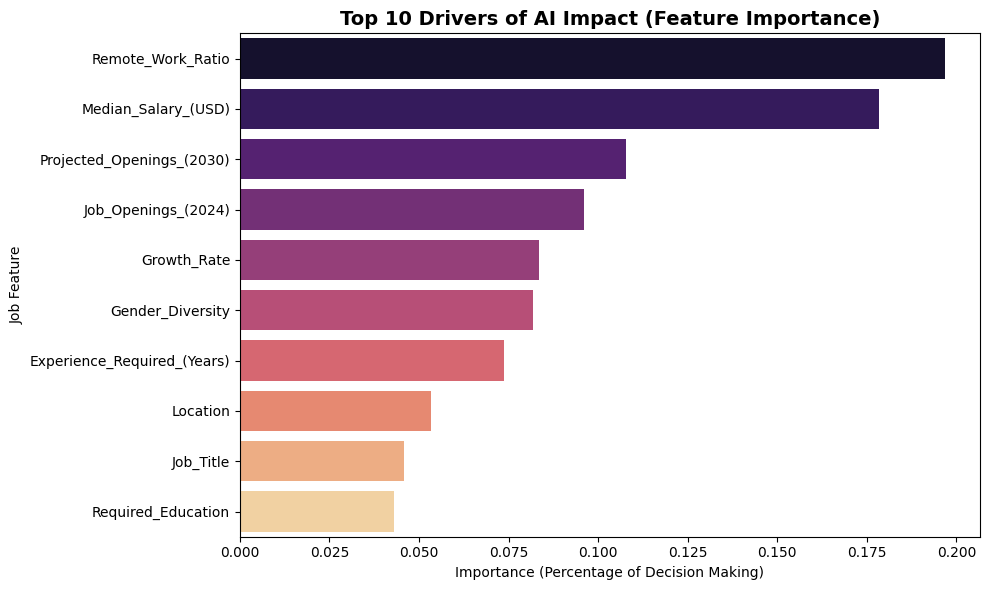

In [42]:

importances = rf_model.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Drivers of AI Impact (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Percentage of Decision Making)')
plt.ylabel('Job Feature')
plt.tight_layout()
plt.show()